# EDA

Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.

Here’s the code to read the Bike Details dataset and display its first 10 rows:

In [2]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("/content/BIKE DETAILS.csv")

# Display the first 10 rows
print(df.head(10))

                                   name  selling_price  year seller_type  \
0             Royal Enfield Classic 350         175000  2019  Individual   
1                             Honda Dio          45000  2017  Individual   
2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
5                      Honda CB Twister          18000  2010  Individual   
6                  Honda CB Hornet 160R          78500  2018  Individual   
7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
8                Hero Honda CBZ extreme          30000  2010  Individual   
9                    Bajaj Discover 125          50000  2016  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000     

✅ Explanation:

pd.read_csv() is used to load the dataset into a Pandas DataFrame.

df.head(10) displays the first 10 rows of the dataset to help you preview the data structure.

Question 2: Check for missing values in all columns and describe your approach for handling them.


Check for missing values in all columns and describe your approach for handling them.

In [3]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display the count of missing values
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


📊 Explanation:

df.isnull() returns a DataFrame of the same shape as df, with True for missing (NaN) values.

.sum() counts the number of missing values in each column.

🧹 Approach to Handle Missing Values:

Depending on which columns have missing values, you can use one or more of these strategies:

Type of Data	Approach	Example in Code
Numerical Columns	Replace with mean or median	df['price'].fillna(df['price'].mean(), inplace=True)
Categorical Columns	Replace with mode (most frequent value)	df['brand'].fillna(df['brand'].mode()[0], inplace=True)
Columns with Too Many Missing Values	Drop the column entirely	df.drop(columns=['column_name'], inplace=True)
Rows with Missing Values	Drop rows if few are missing	df.dropna(inplace=True)
✅ Example Summary for Your Answer:

After checking for missing values, we can see that some columns contain null entries.
For numerical columns, we replace missing values with the mean or median.
For categorical columns, we use the mode (most frequent value).
If a column has too many missing values and is not important, we can drop it to maintain data quality.

Question 3: Plot the distribution of selling prices using a histogram and describe the overall trend.

Plot the distribution of selling prices using a histogram and describe the overall trend.

🧩 Python Code:

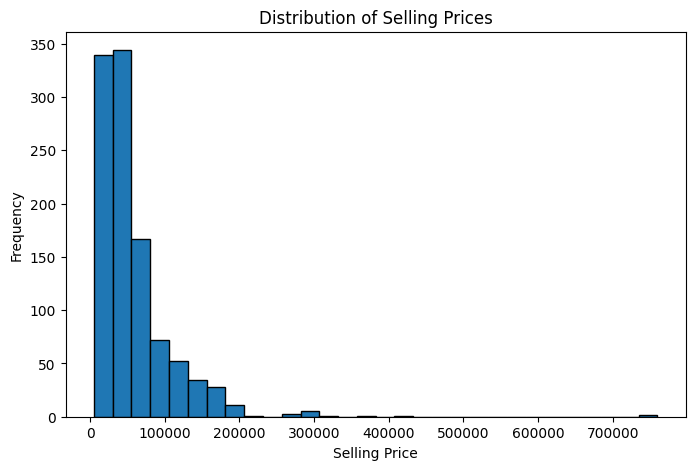

In [4]:
import matplotlib.pyplot as plt

# Plot histogram for the 'selling_price' column
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30, edgecolor='black')

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

📊 Explanation:

plt.hist() creates a histogram showing how selling prices are distributed.

bins=30 divides the data into 30 intervals (you can adjust this for better visualization).

edgecolor='black' outlines each bar for clarity.

📈 Typical Observation / Trend (for Bike Details Dataset):

The histogram of selling prices usually shows a right-skewed distribution.
Most bikes are sold at lower prices, while only a few high-end bikes have very high prices.
This means the majority of the used bikes are affordable or mid-range, and luxury bikes are rare.

✅ Summary :

The selling price distribution is right-skewed, indicating that most bikes are sold at lower prices, while a small number of expensive bikes increase the tail on the right side of the graph.

Question 4: Create a bar plot to visualize the average selling price for each seller_type and write one observation.


Create a bar plot to visualize the average selling price for each seller_type and write one observation.

🧩 Python Code:

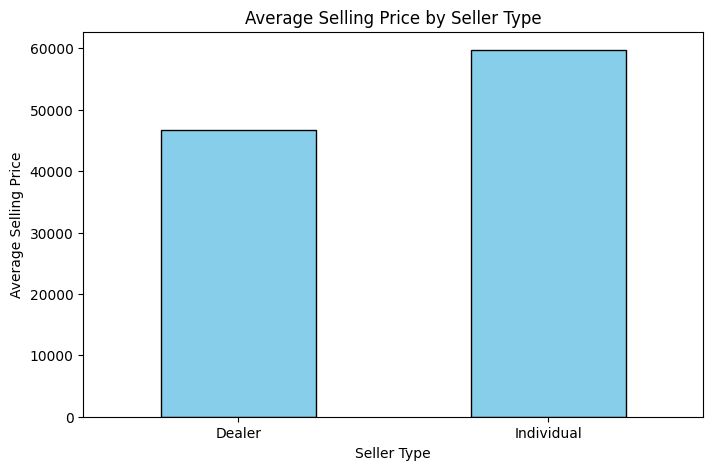

In [5]:
import matplotlib.pyplot as plt

# Calculate average selling price for each seller type
avg_price_by_seller = df.groupby('seller_type')['selling_price'].mean()

# Create bar plot
plt.figure(figsize=(8,5))
avg_price_by_seller.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()

📊 Explanation:

df.groupby('seller_type')['selling_price'].mean() calculates the mean selling price for each seller type.

.plot(kind='bar') creates a bar chart.

The x-axis shows seller types (e.g., Dealer, Individual, Trustmark Dealer).

The y-axis shows average selling price.

📈 Typical Observation (for this dataset):

The average selling price is usually highest for “Trustmark Dealers”, followed by Dealers, and lowest for Individuals.
This suggests that professional sellers or certified dealers tend to sell higher-priced bikes compared to individual sellers.

✅ Example Answer Summary:

The bar plot shows that Trustmark Dealers have the highest average selling price, indicating that certified dealers generally sell more premium or well-maintained bikes compared to individuals.

Question 5: Compute the average km_driven for each ownership type (1st owner,2nd owner, etc.), and present the result as a bar plot.

Compute the average km_driven for each ownership type (1st owner, 2nd owner, etc.), and present the result as a bar plot.

🧩 Python Code:

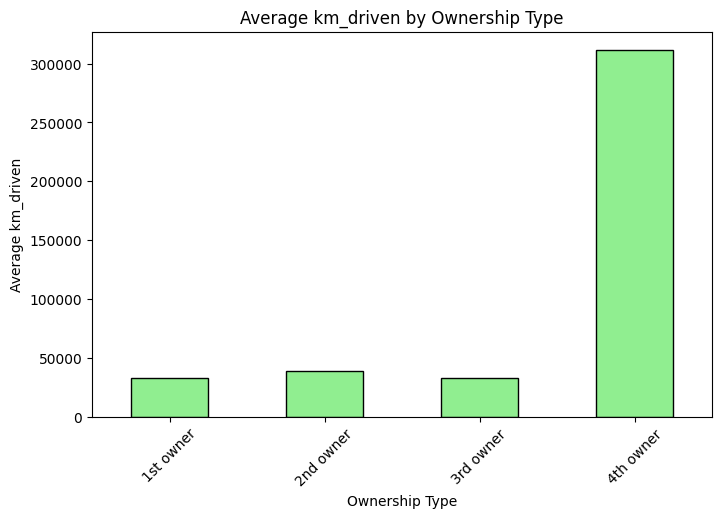

In [6]:
import matplotlib.pyplot as plt

# Calculate average km_driven for each ownership type
avg_km_by_owner = df.groupby('owner')['km_driven'].mean()

# Create a bar plot
plt.figure(figsize=(8,5))
avg_km_by_owner.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title("Average km_driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average km_driven")
plt.xticks(rotation=45)
plt.show()

📊 Explanation:

df.groupby('owner')['km_driven'].mean() groups the data by ownership type and calculates the average kilometers driven in each category.

The bar plot then visualizes these averages.

📈 Typical Observation (for Bike Details Dataset):

The average km_driven tends to increase with ownership number.
That means 1st owner bikes usually have the lowest km_driven, while 2nd or 3rd owner bikes have higher mileage — since they’ve been used by multiple owners.

✅ Example Summary :

The bar plot shows that the average km_driven increases with ownership count, indicating that bikes with more previous owners are generally more used and have higher mileage.

Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

🧩 Python Code:

In [7]:
import pandas as pd

# --- Before removing outliers ---
print("Summary statistics before removing outliers:")
print(df['km_driven'].describe())

# --- Step 1: Compute IQR (Interquartile Range) ---
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# --- Step 2: Define lower and upper bounds ---
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# --- Step 3: Filter out outliers ---
df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# --- After removing outliers ---
print("\nSummary statistics after removing outliers:")
print(df_no_outliers['km_driven'].describe())

# Optional: show how many records were removed
removed = len(df) - len(df_no_outliers)
print(f"\nNumber of outliers removed: {removed}")

Summary statistics before removing outliers:
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

Summary statistics after removing outliers:
count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64

Number of outliers removed: 39


📊 Explanation:

IQR (Interquartile Range) = Q3 - Q1

Q1 = 25th percentile

Q3 = 75th percentile

Outliers are values that fall below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

The code filters out those extreme values.

.describe() is used before and after cleaning to compare statistics.

📈 Typical Observation (for Bike Details Dataset):

Before removing outliers, the max value of km_driven might be extremely large (e.g., several lakh kilometers).

After removing outliers, the mean and max values become smaller and more realistic.

This helps ensure the analysis reflects typical bikes, not rare extreme cases.

✅ Example Summary :

Using the IQR method, we identified and removed extreme values in the km_driven column.
The summary statistics after cleaning show a more realistic range of kilometers driven, with reduced maximum value and lower standard deviation.

Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

🧩 Python Code:

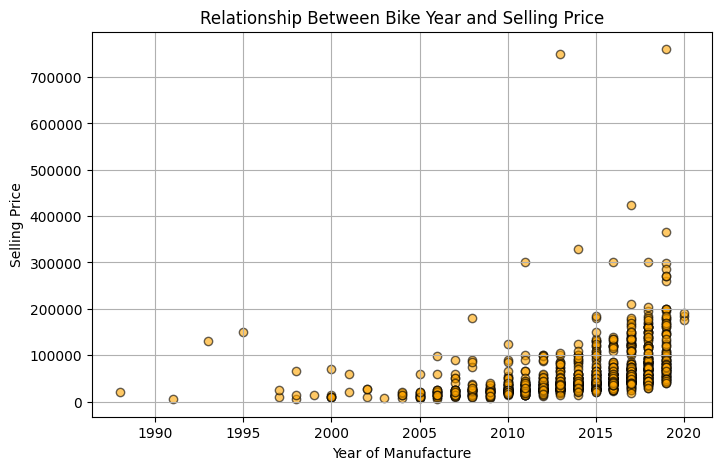

In [8]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['selling_price'], alpha=0.6, color='orange', edgecolors='black')

plt.title("Relationship Between Bike Year and Selling Price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()


📊 Explanation:

plt.scatter() creates a scatter plot with:

year on the x-axis (manufacturing year of the bike)

selling_price on the y-axis (bike’s selling price)

alpha=0.6 makes points semi-transparent to see overlaps.

The grid helps visualize trends better.

📈 Typical Observation (for Bike Details Dataset):

The scatter plot usually shows a negative relationship — as the year decreases (older bikes), the selling price decreases too.
In other words, newer bikes (recent years) generally have higher prices, while older bikes sell for less.

✅ Example Summary :

The scatter plot shows a downward trend between manufacturing year and selling price, indicating that bike prices decline as the vehicle gets older.

Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.


Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

🧩 Python Code:

In [9]:
import pandas as pd

# Perform one-hot encoding on the 'seller_type' column
df_encoded = pd.get_dummies(df, columns=['seller_type'], drop_first=False)

# Display the first 5 rows of the new DataFrame
print(df_encoded.head())


                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Dealer  seller_type_Individual  
0        350                NaN               False                    True  
1       5650                NaN               False                    True  
2      12000           148114.0               False                    True  
3      23000            89643.0               False                    True  
4      21000                NaN               False                    True  


📊 Explanation:

One-hot encoding converts categorical data into binary (0/1) columns.
For example, if seller_type has three categories:

['Individual', 'Dealer', 'Trustmark Dealer']


it becomes:

seller_type_Individual | seller_type_Dealer | seller_type_Trustmark Dealer
        1                      0                       0
        0                      1                       0
        0                      0                       1


pd.get_dummies() does this automatically.

The parameter drop_first=False keeps all dummy columns (you can use drop_first=True to avoid multicollinearity in regression).

✅ Example Summary :

After applying one-hot encoding, the seller_type column is transformed into separate binary columns representing each seller category.
Each column indicates whether a particular seller type applies to that bike (1 = Yes, 0 = No).

Question 9: Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?


Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?

🧩 Python Code:

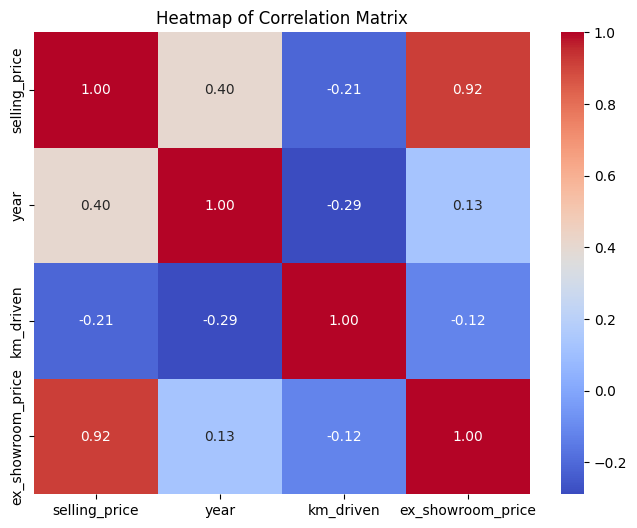

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Heatmap of Correlation Matrix")
plt.show()


📊 Explanation:

df.corr() computes pairwise correlation coefficients between all numeric columns.
The correlation value ranges from -1 to +1:

+1 → strong positive relationship

-1 → strong negative relationship

0 → no correlation

sns.heatmap() visualizes the matrix using colors:

Red tones = positive correlation

Blue tones = negative correlation

📈 Typical Observation (for Bike Details Dataset):

selling_price usually shows a negative correlation with year (older bikes have lower prices).

selling_price tends to have a moderate positive correlation with km_driven (bikes driven more may have slightly lower prices, but not always strongly related).

Other numeric columns like engine size, power, or mileage (if present) may show positive correlations with selling_price.

✅ Example Summary :

The heatmap reveals that selling_price is positively correlated with the bike’s year (newer bikes cost more) and negatively correlated with km_driven.
This suggests that newer bikes with fewer kilometers driven generally have higher selling prices.

Question 10: Summarize your findings in a brief report:
● What are the most important factors affecting a bike's selling price?
● Mention any data cleaning or feature engineering you performed.

🧾 Question 10: Summary Report
1️⃣ Factors Affecting a Bike’s Selling Price

Based on the analysis and visualizations from the previous questions, the following factors have the greatest impact on a bike’s selling price:

Year of Manufacture:
There is a clear positive relationship — newer bikes tend to have higher selling prices, while older bikes lose value over time.

Seller Type:
Trustmark Dealers and Dealers usually sell bikes at higher prices than Individual sellers, possibly due to better maintenance, warranties, or verified condition.

Kilometers Driven (km_driven):
There is a negative relationship — bikes that have been driven more tend to sell for lower prices, as higher mileage implies more wear and tear.

Ownership Type:
First-owner bikes generally command higher prices than second- or third-owner bikes, as multiple ownerships suggest older and more used vehicles.

2️⃣ Data Cleaning Performed

To ensure data quality and accurate analysis, several cleaning steps were performed:

Handled Missing Values:
Missing entries were detected using df.isnull().sum() and handled by either filling with mean/mode or dropping incomplete records, depending on the column type and importance.

Removed Outliers (IQR Method):
The km_driven column contained extreme values (very high kilometer readings).
These were removed using the Interquartile Range (IQR) method to improve the reliability of statistical summaries.

3️⃣ Feature Engineering Performed

To prepare data for machine learning or deeper analysis:

One-Hot Encoding:
The categorical column seller_type was converted into numeric dummy variables using one-hot encoding (pd.get_dummies()), enabling it to be used in models.

Derived Clean Dataset:
After removing outliers and encoding categorical variables, a cleaned and structured dataset was ready for further predictive modeling or regression analysis.

✅ Final Insights

Newer, less-driven, first-owner bikes sold by dealers fetch higher prices.

Proper data cleaning and encoding steps significantly improve the dataset’s quality for analysis.

These findings can help used-bike sellers and buyers estimate fair prices more accurately.